In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

In [2]:
df = pd.read_csv(r"C:\Users\cecil\Cript_Anomalies\BTCUSDT_20180101_20260112.csv", delimiter=";", skiprows=0)
display(df)

,open_time,open,high,low,close,volume,close_time,quote_asset_volume,n_trades,taker_buy_base,...,ignore,symbol,interval,log_return,volatility_20,range_hl,trades_per_volume,buy_ratio,z_return,anomaly_simple
0,2018-01-01 00:00:00+00:00,13715.65,13715.65,13400.01,13556.15,123.616013,2018-01-01 00:14:59.999000+00:00,1.675545e+06,1572,63.227133,...,0,BTCUSDT,15m,NaN,NaN,0.023013,12.716799,0.511480,NaN,False
1,2018-01-01 00:15:00+00:00,13533.75,13550.87,13402.00,13521.12,98.136430,2018-01-01 00:29:59.999000+00:00,1.321757e+06,1461,47.686389,...,0,BTCUSDT,15m,-0.002587,NaN,0.011000,14.887438,0.485919,-0.691986,False
2,2018-01-01 00:30:00+00:00,13500.00,13545.37,13450.00,13470.41,79.904037,2018-01-01 00:44:59.999000+00:00,1.078825e+06,1000,43.710406,...,0,BTCUSDT,15m,-0.003757,NaN,0.007064,12.515012,0.547036,-1.004095,False
3,2018-01-01 00:45:00+00:00,13494.65,13690.87,13450.00,13529.01,141.699719,2018-01-01 00:59:59.999000+00:00,1.917783e+06,1195,73.897993,...,0,BTCUSDT,15m,0.004341,NaN,0.017849,8.433327,0.521511,1.156086,False
4,2018-01-01 01:00:00+00:00,13528.99,13571.74,13402.28,13445.63,72.537533,2018-01-01 01:14:59.999000+00:00,9.778198e+05,898,34.257652,...,0,BTCUSDT,15m,-0.006182,NaN,0.012526,12.379798,0.472275,-1.650855,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
281126,2026-01-12 22:30:00+00:00,91269.52,91402.81,91203.69,91339.90,86.681550,2026-01-12 22:44:59.999000+00:00,7.912440e+06,28813,50.482400,...,0,BTCUSDT,15m,0.000771,0.001837,0.002182,332.400609,0.582389,0.203804,False
281127,2026-01-12 22:45:00+00:00,91339.89,91339.90,91214.00,91244.99,60.451790,2026-01-12 22:59:59.999000+00:00,5.517664e+06,19198,18.105290,...,0,BTCUSDT,15m,-0.001040,0.001788,0.001378,317.575377,0.299500,-0.279123,False
281128,2026-01-12 23:00:00+00:00,91244.99,91280.99,91059.88,91160.07,180.361250,2026-01-12 23:14:59.999000+00:00,1.643558e+07,26239,91.014310,...,0,BTCUSDT,15m,-0.000931,0.001721,0.002423,145.480251,0.504622,-0.250178,False
281129,2026-01-12 23:15:00+00:00,91160.07,91282.39,91135.58,91269.34,31.328540,2026-01-12 23:29:59.999000+00:00,2.857620e+06,9456,19.653920,...,0,BTCUSDT,15m,0.001198,0.001643,0.001610,301.833408,0.627349,0.317736,False


In [3]:
def evaluar_modelo(
    df_result: pd.DataFrame,
    anomaly_col: str = "anomaly_if",
    score_col: str = "if_score",
    zscore_col: str = "anomaly_simple",
    y_true_col: str = None
):
    """
    Calcula métricas estandarizadas para Isolation Forest.

    Métricas:
    - Anomaly Rate
    - Distribución del score
    - Overlap con Z-score, si existe anomaly_simple
    - Precision, Recall, F1 y AUC, si existe variable real y_true_col
    """

    df_eval = df_result.copy()

    # Nos quedamos solo con filas donde el modelo sí predijo
    df_eval = df_eval.dropna(subset=[anomaly_col, score_col])

    y_pred = df_eval[anomaly_col].astype(bool)
    scores = df_eval[score_col].astype(float)

    metricas = {}

    # 1. Total de observaciones evaluadas
    metricas["total_observaciones"] = len(df_eval)

    # 2. Total de anomalías detectadas
    metricas["total_anomalias"] = int(y_pred.sum())

    # 3. Anomaly Rate
    metricas["anomaly_rate"] = y_pred.mean()

    # 4. Distribución del score
    metricas["score_media"] = scores.mean()
    metricas["score_std"] = scores.std()
    metricas["score_min"] = scores.min()
    metricas["score_p50"] = scores.quantile(0.50)
    metricas["score_p95"] = scores.quantile(0.95)
    metricas["score_p99"] = scores.quantile(0.99)
    metricas["score_max"] = scores.max()

    # 5. Overlap con Z-score
    if zscore_col in df_eval.columns:
        z_anom = df_eval[zscore_col].astype(bool)

        anom_modelo = set(df_eval.index[y_pred])
        anom_zscore = set(df_eval.index[z_anom])

        interseccion = anom_modelo.intersection(anom_zscore)

        metricas["zscore_total_anomalias"] = len(anom_zscore)
        metricas["overlap_zscore_n"] = len(interseccion)

        if len(anom_zscore) > 0:
            metricas["overlap_zscore_pct"] = len(interseccion) / len(anom_zscore)
        else:
            metricas["overlap_zscore_pct"] = np.nan

    # 6. Métricas supervisadas si existe etiqueta real
    if y_true_col is not None and y_true_col in df_eval.columns:
        y_true = df_eval[y_true_col].astype(bool)

        metricas["precision"] = precision_score(y_true, y_pred, zero_division=0)
        metricas["recall"] = recall_score(y_true, y_pred, zero_division=0)
        metricas["f1_score"] = f1_score(y_true, y_pred, zero_division=0)

        try:
            metricas["auc"] = roc_auc_score(y_true, scores)
        except ValueError:
            metricas["auc"] = np.nan

    return pd.DataFrame([metricas])

In [4]:
def one_class_svm_anomaly_detection(
    df: pd.DataFrame,
    feature_cols: list,
    nu: float = 0.01,          # proporción esperada de anomalías
    kernel: str = "rbf",
    gamma: str = "scale"
):
    
    df_model = df.copy()
    
    # Eliminar NaN
    df_model = df_model.dropna(subset=feature_cols)
    
    # Escalamiento
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_model[feature_cols])
    
    # Modelo One-Class SVM
    model = OneClassSVM(
        kernel=kernel,
        nu=nu,
        gamma=gamma
    )
    
    model.fit(X_scaled)
    
    # Predicciones
    preds = model.predict(X_scaled)
    scores = model.decision_function(X_scaled)
    
    # sklearn devuelve:
    # 1  = normal
    # -1 = anomalía
    
    df_model["anomaly_ocsvm"] = (preds == -1).astype(int)
    df_model["ocsvm_score"] = scores
    
    return df_model, model, scaler

In [5]:
def plot_ocsvm_results(df, price_col="close"):
    
    plt.figure(figsize=(14,6))
    
    plt.plot(df[price_col], label="Precio Close", alpha=0.7)
    
    anomalies = df[df["anomaly_ocsvm"] == 1]
    
    plt.scatter(
        anomalies.index,
        anomalies[price_col],
        color="red",
        label="Anomalías (OC-SVM)",
        s=20
    )
    
    plt.legend()
    plt.title("One-Class SVM - Detección de Anomalías")
    plt.show()

In [6]:
def plot_ocsvm_scatter_2features(
    df,
    x_col,
    y_col,
    anomaly_col="anomaly_ocsvm",
    title="Detección de Anomalías con One-Class SVM"
):
    d = df.dropna(subset=[x_col, y_col, anomaly_col]).copy()

    plt.figure(figsize=(12, 7))

    # Todos los puntos
    plt.scatter(d[x_col], d[y_col], alpha=0.7, label="Datos")

    # Anomalías (círculo rojo)
    an = d[d[anomaly_col] == 1]
    plt.scatter(
        an[x_col], an[y_col],
        facecolors="none", edgecolors="red", s=140, linewidths=2,
        label="Anomalías Detectadas"
    )

    plt.title(title)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.legend()
    plt.show()

In [7]:

def plot_ocsvm_scatter_pca2(
    df,
    feature_cols,
    anomaly_col="anomaly_ocsvm",
    title="Detección de Anomalías con One-Class SVM (PCA 2D)",
    sample_n=None,          # opcional: para acelerar si tienes muchos puntos
    random_state=42
):
    d = df.dropna(subset=feature_cols + [anomaly_col]).copy()

    # (opcional) muestreo para que no pese tanto
    if sample_n is not None and len(d) > sample_n:
        d = d.sample(sample_n, random_state=random_state)

    # Escalar + PCA
    X = d[feature_cols].values
    Xs = StandardScaler().fit_transform(X)
    X2 = PCA(n_components=2, random_state=random_state).fit_transform(Xs)

    plt.figure(figsize=(12, 7))

    # Todos los puntos (azul)
    plt.scatter(X2[:, 0], X2[:, 1], alpha=0.7, label="Datos")

    # Anomalías (círculo rojo)
    mask_an = d[anomaly_col].values.astype(int) == 1
    plt.scatter(
        X2[mask_an, 0], X2[mask_an, 1],
        facecolors="none", edgecolors="red", s=140, linewidths=2,
        label="Anomalías Detectadas"
    )

    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.show()

In [13]:
def plot_pca_score(df, features, score_col, title="PCA 2D coloreado por score", cmap="RdYlGn_r", sample_n=30000, random_state=42):
    d = df.dropna(subset=features + [score_col]).copy()
    if len(d) > sample_n:
        d = d.sample(sample_n, random_state=random_state)

    X = d[features].replace([np.inf, -np.inf], np.nan).dropna()
    d = d.loc[X.index]
    scores = d[score_col].values

    Xs = StandardScaler().fit_transform(X.values)
    X2 = PCA(n_components=2, random_state=random_state).fit_transform(Xs)

    plt.figure()
    sc = plt.scatter(X2[:, 0], X2[:, 1], c=scores, cmap=cmap)
    plt.colorbar(sc, label="Anomaly Score")
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

In [8]:
features = [
    "log_return",
    "volatility_20",
    "range_hl",
    "trades_per_volume",
    "buy_ratio"
]

In [9]:
df_clean = df.copy()

# 1) quitar inf
df_clean[features] = df_clean[features].replace([np.inf, -np.inf], np.nan)

# 2) eliminar filas con NA en features
df_clean = df_clean.dropna(subset=features).reset_index(drop=True)

In [10]:
df_ocsvm, ocsvm_model, scaler_ocsvm = one_class_svm_anomaly_detection(
    df=df_clean,
    feature_cols=features,
    nu=0.01
)

In [11]:
print(df_ocsvm.columns)

Index(['open_time', 'open', 'high', 'low', 'close', 'volume', 'close_time',
       'quote_asset_volume', 'n_trades', 'taker_buy_base', 'taker_buy_quote',
       'ignore', 'symbol', 'interval', 'log_return', 'volatility_20',
       'range_hl', 'trades_per_volume', 'buy_ratio', 'z_return',
       'anomaly_simple', 'anomaly_ocsvm', 'ocsvm_score'],
      dtype='object')


In [12]:
metrics_ocsv = evaluar_modelo(
    df_result=df_ocsvm,
    anomaly_col='anomaly_ocsvm',
    score_col='ocsvm_score',
    zscore_col="anomaly_simple"
)

print(metrics_ocsv)

   total_observaciones  total_anomalias  anomaly_rate  score_media  score_std  \
0               281097             2808      0.009989     8.595464   4.129446   

   score_min  score_p50  score_p95  score_p99  score_max  \
0 -57.384992   8.898757  13.605809  15.125227  18.118087   

   zscore_total_anomalias  overlap_zscore_n  overlap_zscore_pct  
0                    4819              1266             0.26271  


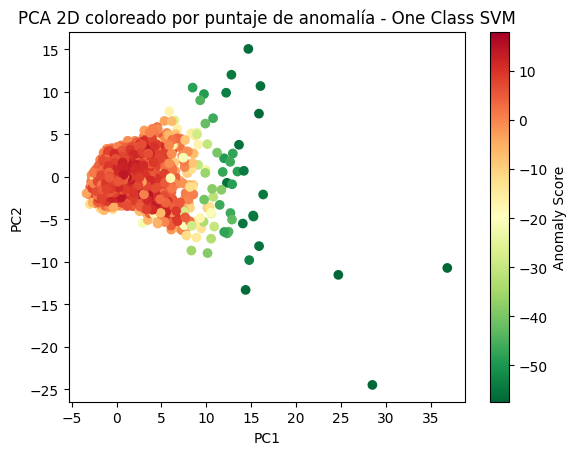

In [14]:
plot_pca_score(
    df=df_ocsvm,
    features=features,
    score_col='ocsvm_score',
    title="PCA 2D coloreado por puntaje de anomalía - One Class SVM"
)

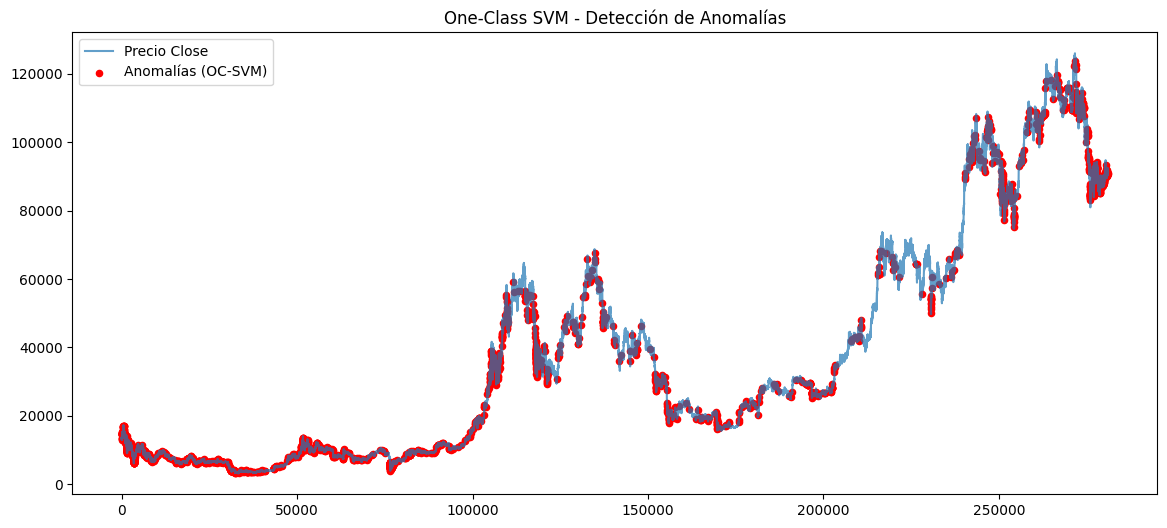

In [12]:
plot_ocsvm_results(df_ocsvm)

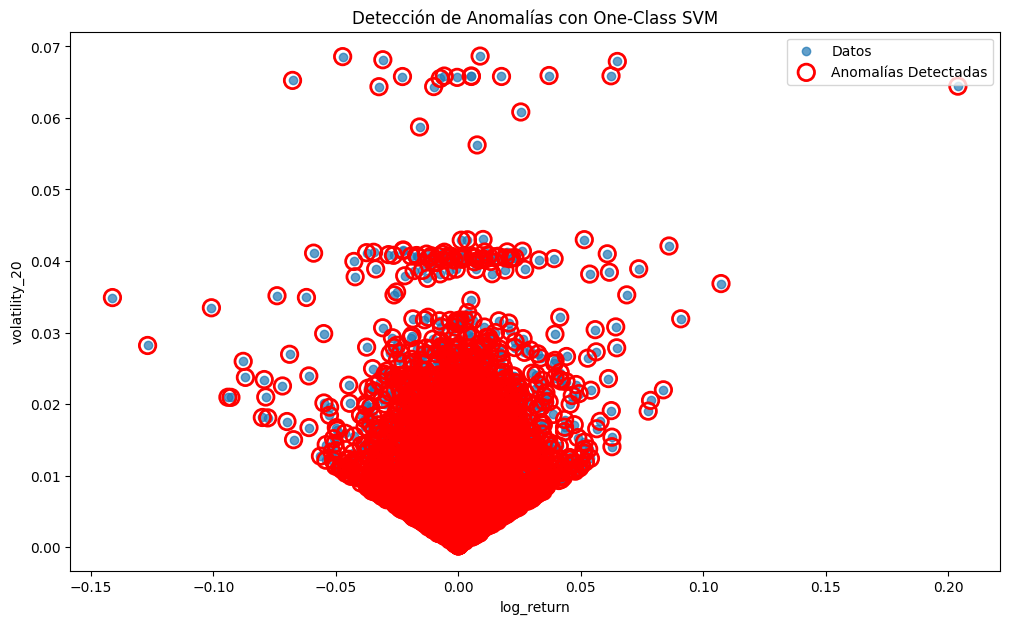

In [13]:
plot_ocsvm_scatter_2features(
    df_ocsvm,
    x_col="log_return",
    y_col="volatility_20"
)

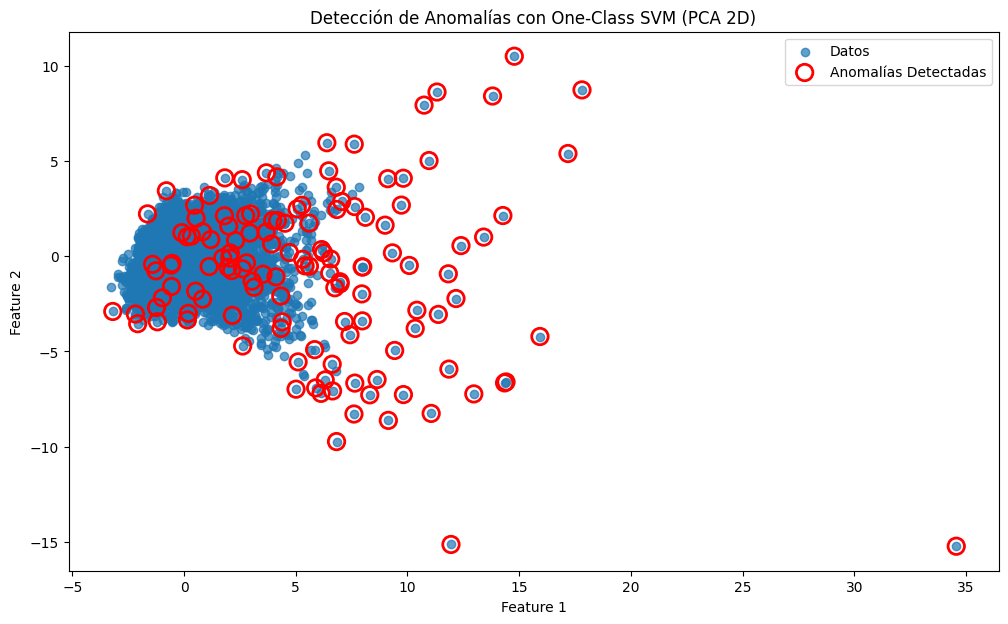

In [14]:
plot_ocsvm_scatter_pca2(
    df_ocsvm,
    feature_cols=features,
    sample_n=15000  # si tienes muchísimos puntos; si no, quítalo
)